---

# Scenario 2 - Smart Student Deadline & Workload Automation System

---

## Scenario Overview

This scenario demonstrates an automation system designed to help students manage academic tasks and deadlines more efficiently.

The scenario is a **Smart Student Deadline & Workload Automation System**. It automatically monitors student assignments, calculates deadline pressure, estimates remaining workload, generates reminders, saves logs, creates backups, and visualizes the results.

## Automation Objectives

The system automates:

1. Student task data creation and loading.
2. Deadline tracking.
3. Workload and urgency score calculation.
4. Priority classification.
5. Reminder generation.
6. Report, log, and backup creation.
7. Dashboard-style visualization.

## Ubuntu Automation Concepts Used

- Linux folder and file management.
- Ubuntu-style log files.
- Backup automation.
- Simulated cron-style scheduled execution.
- Python automation scripts.
- Data visualization for monitoring.

## Step 1: Environment Setup

This cell should be run first. It imports all required libraries and creates the folders used by the automation system.

In [ ]:
import os
import platform
import subprocess
from pathlib import Path
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path("/content/student_automation")
DATA_DIR = BASE_DIR / "data"
LOG_DIR = BASE_DIR / "logs"
BACKUP_DIR = BASE_DIR / "backups"
REPORT_DIR = BASE_DIR / "reports"

for folder in [DATA_DIR, LOG_DIR, BACKUP_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Operating System:", platform.system())
print("Platform:", platform.platform())
print("Current working directory:", os.getcwd())

try:
    print("\nLinux release information:")
    print(subprocess.check_output("cat /etc/os-release | head -5", shell=True).decode())
except Exception as error:
    print("Could not read OS release info:", error)

print("\nAutomation folders created:")
for folder in [DATA_DIR, LOG_DIR, BACKUP_DIR, REPORT_DIR]:
    print("-", folder)

Operating System: Linux
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Current working directory: /content

Linux release information:
PRETTY_NAME="Ubuntu 22.04.5 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.5 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy


Automation folders created:
- /content/student_automation/data
- /content/student_automation/logs
- /content/student_automation/backups
- /content/student_automation/reports


## Step 2: Data Simulation

In a real system, the data could come from Google Calendar, Moodle, Canvas, Blackboard, or a CSV file.

For this assignment, realistic student task data is simulated.

In [ ]:
today = pd.Timestamp(datetime.now().date())

tasks = [
    ["Automation", "Colab automation scenario notebook", today + pd.Timedelta(days=2), 8, 5, 35, "Project"],
    ["Database Systems", "SQL normalization homework", today + pd.Timedelta(days=4), 5, 3, 20, "Homework"],
    ["Operating Systems", "Ubuntu shell scripting lab", today + pd.Timedelta(days=1), 4, 4, 10, "Lab"],
    ["Software Engineering", "Sprint report", today + pd.Timedelta(days=7), 6, 3, 50, "Report"],
    ["Data Analytics", "Visualization dashboard task", today + pd.Timedelta(days=3), 7, 4, 25, "Project"],
    ["Cybersecurity", "Linux permissions quiz", today + pd.Timedelta(days=6), 3, 2, 80, "Quiz"],
    ["Networking", "Packet tracer simulation", today + pd.Timedelta(days=5), 6, 4, 45, "Lab"],
    ["English", "Presentation slides", today + pd.Timedelta(days=9), 4, 2, 30, "Presentation"],
    ["Mathematics", "Linear algebra problem set", today + pd.Timedelta(days=2), 5, 4, 60, "Homework"],
    ["AI Basics", "Mini chatbot reflection", today + pd.Timedelta(days=8), 5, 3, 15, "Reflection"],
]

df = pd.DataFrame(tasks, columns=[
    "course", "task", "deadline", "estimated_hours",
    "difficulty", "completion_percent", "task_type"
])

df["deadline"] = pd.to_datetime(df["deadline"])
input_file = DATA_DIR / "student_tasks.csv"
df.to_csv(input_file, index=False)

print("Simulated student task data saved to:", input_file)
display(df)

Simulated student task data saved to: /content/student_automation/data/student_tasks.csv


,course,task,deadline,estimated_hours,difficulty,completion_percent,task_type
0,Automation,Colab automation scenario notebook,2026-05-30,8,5,35,Project
1,Database Systems,SQL normalization homework,2026-06-01,5,3,20,Homework
2,Operating Systems,Ubuntu shell scripting lab,2026-05-29,4,4,10,Lab
3,Software Engineering,Sprint report,2026-06-04,6,3,50,Report
4,Data Analytics,Visualization dashboard task,2026-05-31,7,4,25,Project
5,Cybersecurity,Linux permissions quiz,2026-06-03,3,2,80,Quiz
6,Networking,Packet tracer simulation,2026-06-02,6,4,45,Lab
7,English,Presentation slides,2026-06-06,4,2,30,Presentation
8,Mathematics,Linear algebra problem set,2026-05-30,5,4,60,Homework
9,AI Basics,Mini chatbot reflection,2026-06-05,5,3,15,Reflection


## Step 3: Automation Logic

The automation engine calculates:

- Days left before the deadline.
- Remaining work hours.
- Urgency score.
- Difficulty score.
- Remaining work score.
- Final workload score.
- Priority level.
- Automated reminder message.

In [ ]:
def calculate_priority(row):
    if row["workload_score"] >= 85:
        return "Critical"
    elif row["workload_score"] >= 65:
        return "High"
    elif row["workload_score"] >= 40:
        return "Medium"
    else:
        return "Low"

def create_reminder(row):
    if row["priority"] == "Critical":
        return (
            "URGENT: Finish '" + row["task"] + "' for " + row["course"] +
            " immediately. Deadline is in " + str(row["days_left"]) + " day(s)."
        )
    elif row["priority"] == "High":
        return (
            "High priority: Work on '" + row["task"] + "' today. Deadline is in " +
            str(row["days_left"]) + " day(s)."
        )
    elif row["priority"] == "Medium":
        return "Plan soon: Schedule time for '" + row["task"] + "' within the next 2 days."
    else:
        return "Low risk: Continue steady progress on '" + row["task"] + "'."

def run_deadline_automation(input_file):
    data = pd.read_csv(input_file)
    data["deadline"] = pd.to_datetime(data["deadline"])

    current_day = pd.Timestamp(datetime.now().date())
    data["days_left"] = (data["deadline"] - current_day).dt.days
    data["remaining_hours"] = data["estimated_hours"] * (1 - data["completion_percent"] / 100)

    data["urgency_score"] = np.clip(50 - (data["days_left"] * 6), 5, 50)
    data["difficulty_score"] = data["difficulty"] * 5
    data["remaining_work_score"] = np.clip(data["remaining_hours"] * 4, 0, 30)

    data["workload_score"] = (
        data["urgency_score"] +
        data["difficulty_score"] +
        data["remaining_work_score"]
    ).round(1)

    data["priority"] = data.apply(calculate_priority, axis=1)
    data["reminder"] = data.apply(create_reminder, axis=1)

    return data.sort_values(["workload_score", "deadline"], ascending=[False, True])

automation_results = run_deadline_automation(DATA_DIR / "student_tasks.csv")
display(automation_results)

,course,task,deadline,estimated_hours,difficulty,completion_percent,task_type,days_left,remaining_hours,urgency_score,difficulty_score,remaining_work_score,workload_score,priority,reminder
0,Automation,Colab automation scenario notebook,2026-05-30,8,5,35,Project,2,5.20,38,25,20.8,83.8,High,High priority: Work on 'Colab automation scena...
2,Operating Systems,Ubuntu shell scripting lab,2026-05-29,4,4,10,Lab,1,3.60,44,20,14.4,78.4,High,High priority: Work on 'Ubuntu shell scripting...
4,Data Analytics,Visualization dashboard task,2026-05-31,7,4,25,Project,3,5.25,32,20,21.0,73.0,High,High priority: Work on 'Visualization dashboar...
8,Mathematics,Linear algebra problem set,2026-05-30,5,4,60,Homework,2,2.00,38,20,8.0,66.0,High,High priority: Work on 'Linear algebra problem...
1,Database Systems,SQL normalization homework,2026-06-01,5,3,20,Homework,4,4.00,26,15,16.0,57.0,Medium,Plan soon: Schedule time for 'SQL normalizatio...
6,Networking,Packet tracer simulation,2026-06-02,6,4,45,Lab,5,3.30,20,20,13.2,53.2,Medium,Plan soon: Schedule time for 'Packet tracer si...
9,AI Basics,Mini chatbot reflection,2026-06-05,5,3,15,Reflection,8,4.25,5,15,17.0,37.0,Low,Low risk: Continue steady progress on 'Mini ch...
3,Software Engineering,Sprint report,2026-06-04,6,3,50,Report,7,3.00,8,15,12.0,35.0,Low,Low risk: Continue steady progress on 'Sprint ...
5,Cybersecurity,Linux permissions quiz,2026-06-03,3,2,80,Quiz,6,0.60,14,10,2.4,26.4,Low,Low risk: Continue steady progress on 'Linux p...
7,English,Presentation slides,2026-06-06,4,2,30,Presentation,9,2.80,5,10,11.2,26.2,Low,Low risk: Continue steady progress on 'Present...


## Step 4: Report Generation

This simulates a scheduled Ubuntu automation script.

A real Ubuntu cron job could run this every morning:

```bash
0 8 * * * python3 /home/student/deadline_automation.py
```

In [ ]:
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

report_file = REPORT_DIR / ("deadline_report_" + timestamp + ".csv")
log_file = LOG_DIR / ("automation_log_" + timestamp + ".txt")
backup_file = BACKUP_DIR / ("student_tasks_backup_" + timestamp + ".csv")

automation_results.to_csv(report_file, index=False)
df.to_csv(backup_file, index=False)

critical_count = int((automation_results["priority"] == "Critical").sum())
high_count = int((automation_results["priority"] == "High").sum())
total_remaining_hours = round(float(automation_results["remaining_hours"].sum()), 1)

log_text = f'''
Smart Student Deadline & Workload Automation Log
Run time: {datetime.now()}
Input file: {DATA_DIR / "student_tasks.csv"}
Report saved: {report_file}
Backup saved: {backup_file}

Summary:
- Total tasks analyzed: {len(automation_results)}
- Critical tasks: {critical_count}
- High priority tasks: {high_count}
- Total remaining work hours: {total_remaining_hours}
'''

with open(log_file, "w") as file:
    file.write(log_text)

print(log_text)
print("Files generated successfully.")


Smart Student Deadline & Workload Automation Log
Run time: 2026-05-28 08:58:56.190683
Input file: /content/student_automation/data/student_tasks.csv
Report saved: /content/student_automation/reports/deadline_report_2026-05-28_08-58-56.csv
Backup saved: /content/student_automation/backups/student_tasks_backup_2026-05-28_08-58-56.csv

Summary:
- Total tasks analyzed: 10
- Critical tasks: 0
- High priority tasks: 4
- Total remaining work hours: 34.0

Files generated successfully.


## Step 5: Reminder Dashboard

This table shows the reminders generated by the automation system.

In [ ]:
reminder_dashboard = automation_results[[
    "course", "task", "deadline", "days_left", "remaining_hours",
    "workload_score", "priority", "reminder"
]].copy()

reminder_dashboard["remaining_hours"] = reminder_dashboard["remaining_hours"].round(1)

display(reminder_dashboard)

,course,task,deadline,days_left,remaining_hours,workload_score,priority,reminder
0,Automation,Colab automation scenario notebook,2026-05-30,2,5.2,83.8,High,High priority: Work on 'Colab automation scena...
2,Operating Systems,Ubuntu shell scripting lab,2026-05-29,1,3.6,78.4,High,High priority: Work on 'Ubuntu shell scripting...
4,Data Analytics,Visualization dashboard task,2026-05-31,3,5.2,73.0,High,High priority: Work on 'Visualization dashboar...
8,Mathematics,Linear algebra problem set,2026-05-30,2,2.0,66.0,High,High priority: Work on 'Linear algebra problem...
1,Database Systems,SQL normalization homework,2026-06-01,4,4.0,57.0,Medium,Plan soon: Schedule time for 'SQL normalizatio...
6,Networking,Packet tracer simulation,2026-06-02,5,3.3,53.2,Medium,Plan soon: Schedule time for 'Packet tracer si...
9,AI Basics,Mini chatbot reflection,2026-06-05,8,4.2,37.0,Low,Low risk: Continue steady progress on 'Mini ch...
3,Software Engineering,Sprint report,2026-06-04,7,3.0,35.0,Low,Low risk: Continue steady progress on 'Sprint ...
5,Cybersecurity,Linux permissions quiz,2026-06-03,6,0.6,26.4,Low,Low risk: Continue steady progress on 'Linux p...
7,English,Presentation slides,2026-06-06,9,2.8,26.2,Low,Low risk: Continue steady progress on 'Present...


## Step 6: Workload Visualization

This chart shows which assignments create the highest workload pressure.

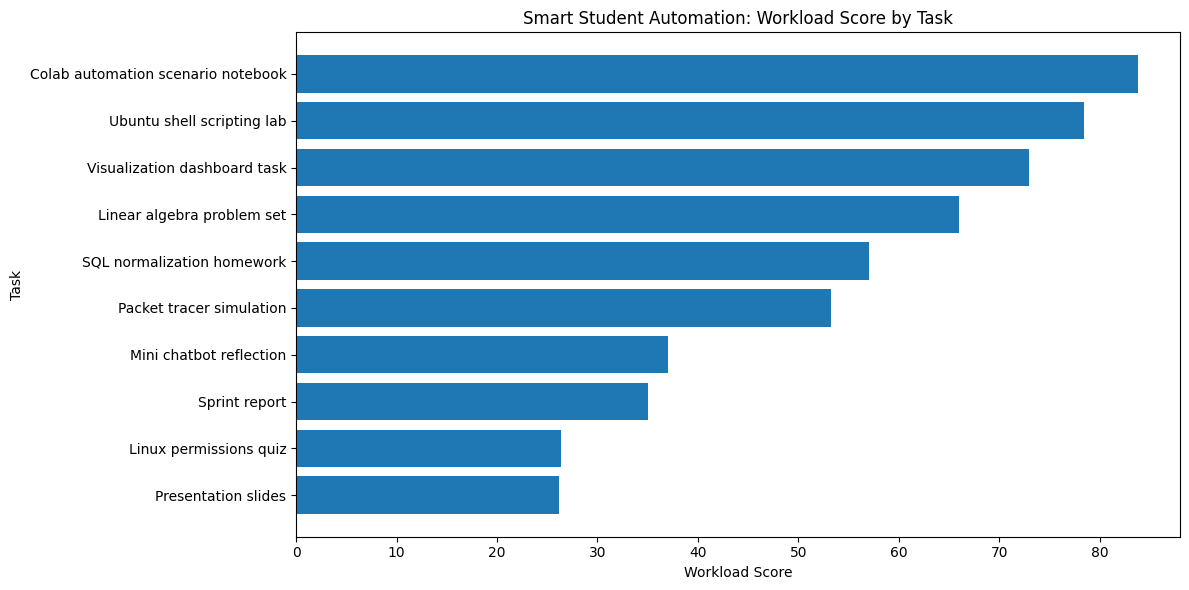

In [ ]:
plot_data = automation_results.sort_values("workload_score", ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(plot_data["task"], plot_data["workload_score"])
plt.xlabel("Workload Score")
plt.ylabel("Task")
plt.title("Smart Student Automation: Workload Score by Task")
plt.tight_layout()
plt.show()

## Step 7: Visualization — Remaining Work Hours by Course

This chart shows which courses require the most remaining effort.

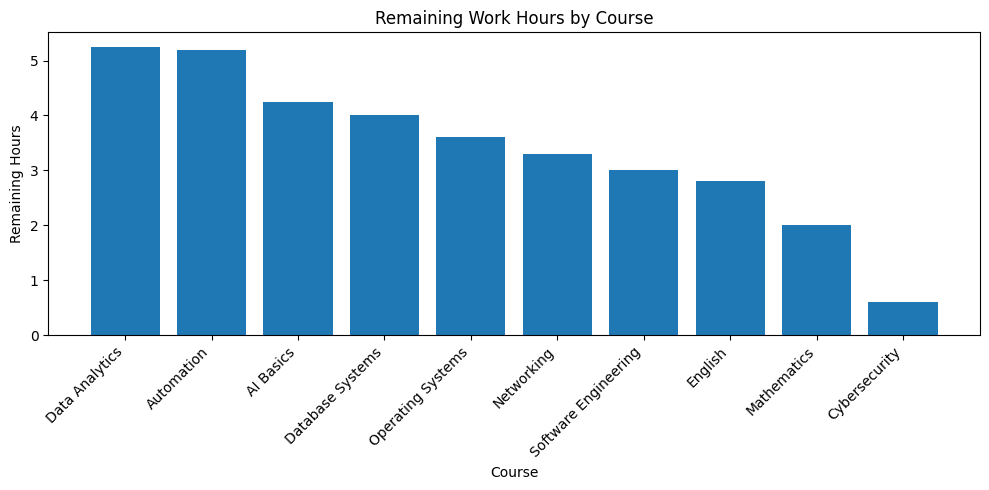

In [ ]:
course_workload = automation_results.groupby("course")["remaining_hours"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(course_workload.index, course_workload.values)
plt.xlabel("Course")
plt.ylabel("Remaining Hours")
plt.title("Remaining Work Hours by Course")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Step 8: Visualization — Deadline Risk Map

This scatter plot shows the relationship between deadline urgency and workload score.

Tasks with high workload and few days left are the most dangerous.

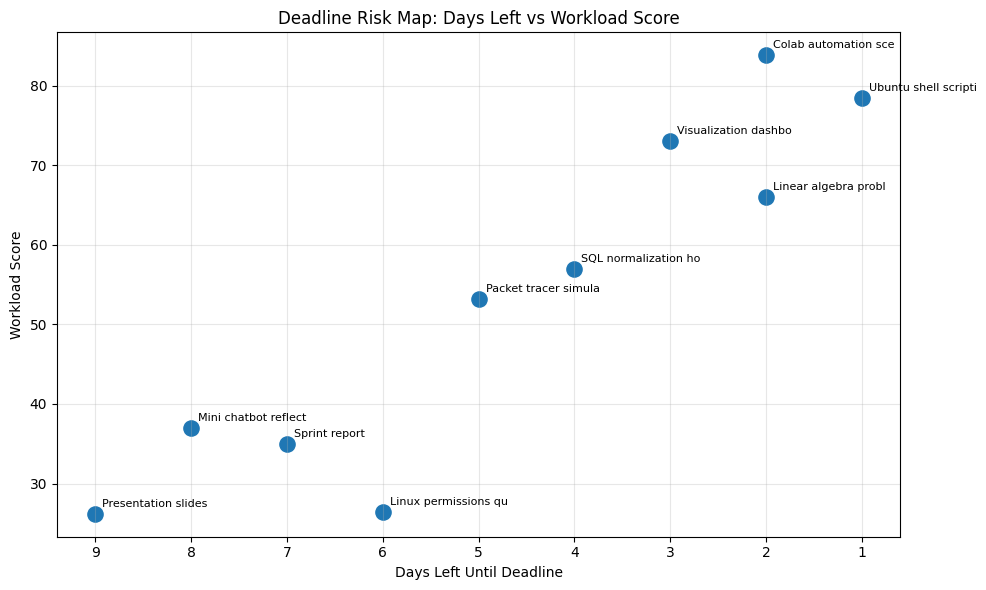

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(automation_results["days_left"], automation_results["workload_score"], s=120)

for _, row in automation_results.iterrows():
    plt.annotate(
        row["task"][:20],
        (row["days_left"], row["workload_score"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Days Left Until Deadline")
plt.ylabel("Workload Score")
plt.title("Deadline Risk Map: Days Left vs Workload Score")
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9: Visualization — Priority Distribution

This chart summarizes how many tasks are low, medium, high, or critical priority.

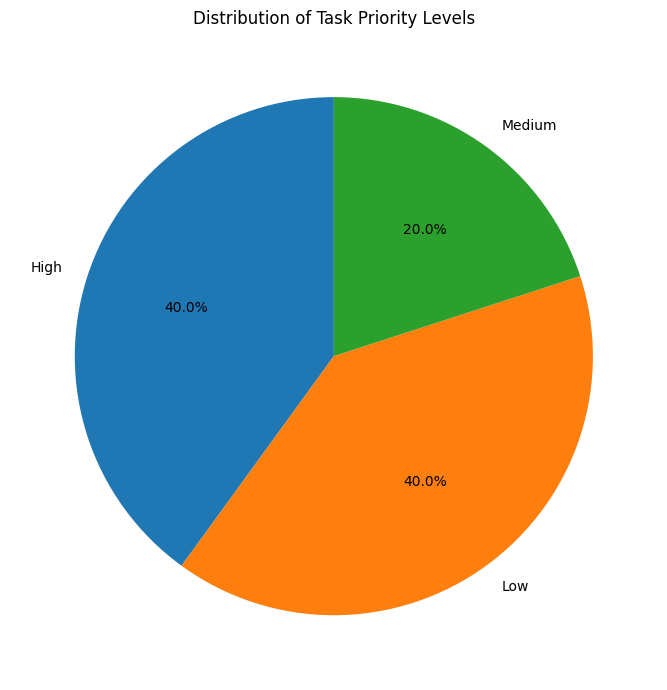

In [ ]:
priority_counts = automation_results["priority"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(priority_counts.values, labels=priority_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Distribution of Task Priority Levels")
plt.tight_layout()
plt.show()

## Step 10: Ubuntu-Style File Inspection

This confirms that the automation created CSV reports, backup files, and log files.

In [ ]:
print("Workspace file structure:")
file_list = subprocess.check_output("find /content/student_automation -type f | sort", shell=True).decode()
print(file_list)

print("\nLatest automation log:")
latest_logs = sorted(LOG_DIR.glob("automation_log_*.txt"))

if latest_logs:
    latest_log = latest_logs[-1]
    print(open(latest_log).read())
else:
    print("No log files found.")

Workspace file structure:
/content/student_automation/backups/student_tasks_backup_2026-05-28_08-46-04.csv
/content/student_automation/backups/student_tasks_backup_2026-05-28_08-46-08.csv
/content/student_automation/backups/student_tasks_backup_2026-05-28_08-46-50.csv
/content/student_automation/backups/student_tasks_backup_2026-05-28_08-46-57.csv
/content/student_automation/backups/student_tasks_backup_2026-05-28_08-47-00.csv
/content/student_automation/backups/student_tasks_backup_2026-05-28_08-47-02.csv
/content/student_automation/backups/student_tasks_backup_2026-05-28_08-47-03.csv
/content/student_automation/backups/student_tasks_backup_2026-05-28_08-47-09.csv
/content/student_automation/backups/student_tasks_backup_2026-05-28_08-58-56.csv
/content/student_automation/data/student_tasks.csv
/content/student_automation/logs/automation_log_2026-05-28_08-46-04.txt
/content/student_automation/logs/automation_log_2026-05-28_08-46-08.txt
/content/student_automation/logs/automation_log_20

## Step 11: Simulated Daily Automation Over One Week

This section simulates the automation running once per day for seven days.

In a real Ubuntu environment, this repeated execution could be handled by cron.

In [ ]:
def simulate_future_run(base_data, simulated_today):
    temp = base_data.copy()
    temp["deadline"] = pd.to_datetime(temp["deadline"])
    temp["days_left"] = (temp["deadline"] - simulated_today).dt.days

    days_passed = int((simulated_today - today).days)
    temp["completion_percent"] = np.clip(temp["completion_percent"] + days_passed * 8, 0, 100)

    temp["remaining_hours"] = temp["estimated_hours"] * (1 - temp["completion_percent"] / 100)
    temp["urgency_score"] = np.clip(50 - (temp["days_left"] * 6), 5, 50)
    temp["difficulty_score"] = temp["difficulty"] * 5
    temp["remaining_work_score"] = np.clip(temp["remaining_hours"] * 4, 0, 30)

    temp["workload_score"] = (
        temp["urgency_score"] +
        temp["difficulty_score"] +
        temp["remaining_work_score"]
    ).round(1)

    temp["priority"] = temp.apply(calculate_priority, axis=1)
    return temp

weekly_summary = []

for day_offset in range(7):
    simulated_today = today + pd.Timedelta(days=day_offset)
    simulated_result = simulate_future_run(df, simulated_today)

    weekly_summary.append({
        "date": simulated_today.date(),
        "average_workload_score": round(float(simulated_result["workload_score"].mean()), 1),
        "critical_tasks": int((simulated_result["priority"] == "Critical").sum()),
        "high_tasks": int((simulated_result["priority"] == "High").sum()),
        "total_remaining_hours": round(float(simulated_result["remaining_hours"].sum()), 1)
    })

weekly_df = pd.DataFrame(weekly_summary)
display(weekly_df)

,date,average_workload_score,critical_tasks,high_tasks,total_remaining_hours
0,2026-05-28,53.6,0,4,34.0
1,2026-05-29,57.0,1,3,29.8
2,2026-05-30,60.4,1,4,25.5
3,2026-05-31,63.0,1,5,21.4
4,2026-06-01,65.0,1,5,17.4
5,2026-06-02,66.4,0,6,13.4
6,2026-06-03,67.3,0,6,9.8


## Step 12: Visualization — Weekly Workload Trend

This chart shows how total remaining workload changes across simulated daily automation runs.

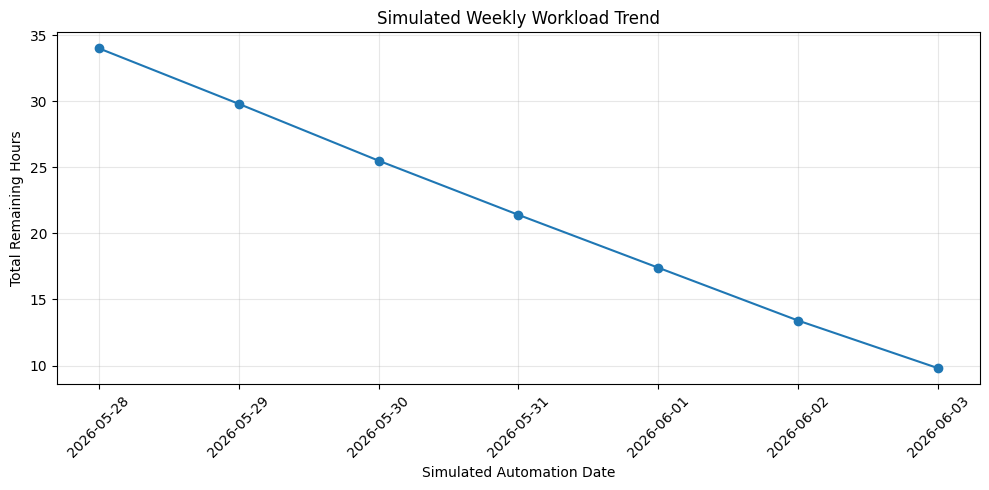

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(weekly_df["date"], weekly_df["total_remaining_hours"], marker="o")
plt.xlabel("Simulated Automation Date")
plt.ylabel("Total Remaining Hours")
plt.title("Simulated Weekly Workload Trend")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Reflection

This assignment helped me gain a better understanding of automation concepts and their practical applications in real-world situations. By designing and implementing an automation scenario in Google Colab, I learned how automated systems can reduce manual effort, improve efficiency, and support decision-making through data processing and visualization.

Through my Smart Student Deadline & Workload Automation System, I applied concepts such as workflow automation, data management, report generation, logging, and task prioritization. I also improved my skills in using Python libraries for data analysis and visualization while working within an Ubuntu-based environment.

One of the key lessons I learned is that automation is not only about executing tasks automatically but also about creating structured systems that can monitor, analyze, and respond to information effectively. Overall, this assignment strengthened both my technical skills and my understanding of how automation can be used to solve practical problems in academic and professional environments.
